In [1]:
import pandas as pd
from trxtools.utils.names import cleanNames
import trxtools.methods as ttm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Load data

Load TPM tables

In [2]:
df00_uniq = pd.read_csv('../03a_FeatureCounts_umitools_overlap/featureCounts_umitools_overlap_uniq_TPM.txt', sep='\t', index_col=0)
df00_uniq = cleanNames(df00_uniq, ['02c_alignment_all_umitools/', '.bam', '_none_400mJ', '_all_dedup', '_R1', 'RPP25L_FH-', 'none_'])
df00_uniq = df00_uniq[['WT_1', 'WT_2', 'RPP25L_1', 'RPP25L_2']]

df01_multi = pd.read_csv('../03a_FeatureCounts_umitools_overlap/featureCounts_umitools_overlap_multimappers_TPM.txt', sep='\t', index_col=0)
df01_multi = cleanNames(df01_multi, ['02c_alignment_all_umitools/', '.bam', '_none_400mJ', '_all_dedup', '_R1', 'RPP25L_FH-', 'none_'])
df01_multi = df01_multi[['WT_1', 'WT_2', 'RPP25L_1', 'RPP25L_2']]

Load TPM tables

## Basic QC

### Number of mapped reads

In [3]:
summary_uniq = pd.read_csv('../03a_FeatureCounts_umitools_overlap/featureCounts_umitools_overlap_uniq.list.summary', sep='\t')
summary_uniq = cleanNames(summary_uniq, ['02c_alignment_all_umitools/', '.bam', '_none_400mJ', '_all_dedup', '_R1', 'RPP25L_FH-', 'none_'])
summary_uniq = summary_uniq[['Status', 'WT_1', 'WT_2', 'RPP25L_1', 'RPP25L_2']]

summary_multi = pd.read_csv('../03a_FeatureCounts_umitools_overlap/featureCounts_umitools_overlap_multimappers.list.summary', sep='\t')
summary_multi = cleanNames(summary_multi, ['02c_alignment_all_umitools/', '.bam', '_none_400mJ', '_all_dedup', '_R1', 'RPP25L_FH-', 'none_'])
summary_multi = summary_multi[['Status', 'WT_1', 'WT_2', 'RPP25L_1', 'RPP25L_2']]

/tmp/ipykernel_38066/2254119678.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(pd.DataFrame(summary_uniq.drop(columns=['Status'])).iloc[0,:].T, palette='tab20', ax=axes[1])


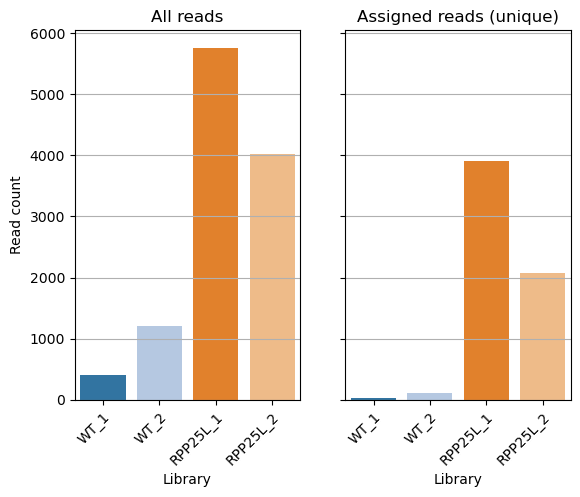

In [4]:
fig, axes = plt.subplots(1,2, sharey=True)
sns.barplot(pd.DataFrame(summary_uniq.sum()).T, palette='tab20', ax=axes[0])
sns.barplot(pd.DataFrame(summary_uniq.drop(columns=['Status'])).iloc[0,:].T, palette='tab20', ax=axes[1])
plt.title("Read count per library")
axes[0].set_ylabel("Read count")
axes[0].set_title("All reads")
axes[1].set_title("Assigned reads (unique)")
for ax in axes:
    ax.grid(axis='y')
    ax.set_xlabel("Library")
    ax.tick_params(axis='x', rotation=45)
    for tick in ax.get_xticklabels():
            tick.set_horizontalalignment("right")
            tick.set_rotation_mode("anchor")
plt.savefig("00_RPP25L_qc_readcounts_unique.png", bbox_inches='tight', dpi=300)

/tmp/ipykernel_38066/3243669627.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(pd.DataFrame(summary_multi.drop(columns=['Status'])).iloc[0,:].T, palette='tab20', ax=axes[1])


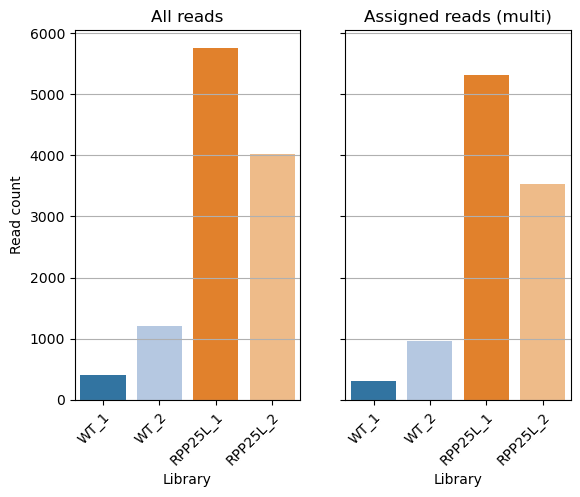

In [5]:
fig, axes = plt.subplots(1,2, sharey=True)
sns.barplot(pd.DataFrame(summary_multi.sum()).T, palette='tab20', ax=axes[0])
sns.barplot(pd.DataFrame(summary_multi.drop(columns=['Status'])).iloc[0,:].T, palette='tab20', ax=axes[1])
# plt.title("Read count per library")
axes[0].set_ylabel("Read count")
axes[0].set_title("All reads")
axes[1].set_title("Assigned reads (multi)")
for ax in axes:
    ax.grid(axis='y')
    ax.set_xlabel("Library")
    ax.tick_params(axis='x', rotation=45)
    for tick in ax.get_xticklabels():
            tick.set_horizontalalignment("right")
            tick.set_rotation_mode("anchor")
plt.savefig("00_RPPL25_qc_readcounts_multi.png", bbox_inches='tight', dpi=300)

### Sample correlations

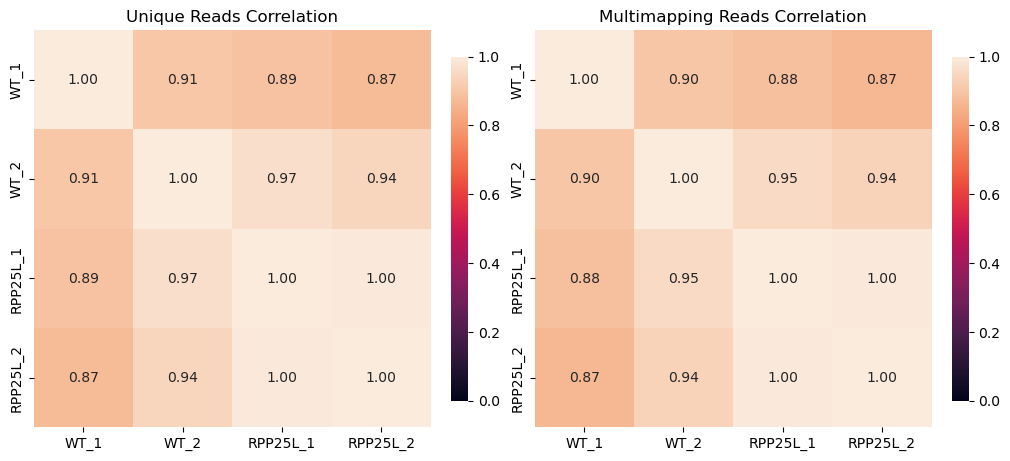

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), layout='constrained')

sns.heatmap(df00_uniq.corr('pearson', numeric_only=True), annot=True, fmt=".2f", square=True, vmin=0, vmax=1, cbar_kws={"shrink": .7}, ax=axes[0])
axes[0].set_title("Unique Reads Correlation")

sns.heatmap(df01_multi.corr('pearson', numeric_only=True), annot=True, fmt=".2f", square=True, vmin=0, vmax=1, cbar_kws={"shrink": .7}, ax=axes[1])
axes[1].set_title("Multimapping Reads Correlation")
plt.savefig("00_RPP25L_qc_correlation_heatmaps.png", dpi=300)

## Read classes
Look at what kinds of loci reads map to

Get gene types from GTF file

In [7]:
gtf = pd.read_csv("../references/hg41_annotation_gencode_tRNA_rRNA.gtf.gz", sep="\t", header=None,compression="gzip")
gtf = gtf[gtf[2].isin(['gene'])]
gtf_classes = gtf[8].str.split("; ", expand=True)[[0,1,2]]
gtf_classes[0] = gtf_classes[0].str.replace('gene_id "', '', regex=False)
gtf_classes[0] = gtf_classes[0].str.replace('"', '', regex=False)
gtf_classes[1] = gtf_classes[1].str.replace('gene_type "', '', regex=False)
gtf_classes[1] = gtf_classes[1].str.replace('"', '', regex=False)
gtf_classes[2] = gtf_classes[2].str.replace('gene_name "', '', regex=False)
gtf_classes[2] = gtf_classes[2].str.replace('"', '', regex=False)   
gtf_classes = gtf_classes.rename(columns={0: 'gene_id', 1: 'gene_type', 2: 'gene_name'})
gtf_classes = gtf_classes.set_index('gene_id')   
gtf_classes.head()
del gtf

Add gene_class info to df's, also fix tRNA class by looking at gene_name

In [8]:
for df_name in [
    "df00_uniq", "df01_multi"
]:
    df = globals()[df_name].drop(columns=gtf_classes.columns, errors='ignore')
    df = pd.concat([df, gtf_classes], axis=1)
    df.loc[df.index.str.contains('tRNA'), 'gene_type'] = 'tRNA'
    mask = df.filter(regex=r'^gene_type$').eq('tRNA').any(axis=1).to_numpy()
    gene_name_positions = [col_idx for col_idx, col in enumerate(df.columns) if col == 'gene_name']
    for pos in gene_name_positions:
        df.iloc[mask, pos] = df.index[mask]
    globals()[df_name] = df

In [9]:
df00_uniq.to_csv("00_RPP25L_featureCounts_TPM_geneclasses_unique.csv")
df01_multi.to_csv("00_RPP25L_featureCounts_TPM_geneclasses_multimapping.csv")

Prepare df for plotting

In [10]:
# Calculate percentages for barplot
bar_uniq = df00_uniq.reset_index().groupby('gene_type').agg('sum', numeric_only=True).T.apply(lambda x: x/sum(x), axis=1) # type: ignore
bar_multi = df01_multi.reset_index().groupby('gene_type').agg('sum', numeric_only=True).T.apply(lambda x: x/sum(x), axis=1)

#filter out some classes and sum them into 'other'
keep = [
    'Mt_rRNA', 'Mt_tRNA', 'lncRNA', 'miRNA',
    'polymorphic_pseudogene',
    'protein_coding', 'rRNA', 'rRNA_pseudogene',
    'snRNA', 'snoRNA', 'tRNA', 'ribozyme'
]

bar_uniq_keep = bar_uniq.loc[:,bar_uniq.columns.isin(keep)]
bar_uniq_keep['rRNA'] = bar_uniq_keep['rRNA'] + bar_uniq_keep['rRNA_pseudogene']
bar_uniq_keep = bar_uniq_keep.drop(columns=['rRNA_pseudogene'])
bar_uniq_plot = pd.concat([bar_uniq_keep, pd.DataFrame(bar_uniq.loc[:,~bar_uniq.columns.isin(keep)].sum(axis=1))], axis=1)
bar_uniq_plot = bar_uniq_plot.rename({0: 'other'}, axis=1)

bar_multi_keep = bar_multi.loc[:,bar_multi.columns.isin(keep)]
bar_multi_keep['rRNA'] = bar_multi_keep['rRNA'] + bar_multi_keep['rRNA_pseudogene']
bar_multi_keep = bar_multi_keep.drop(columns=['rRNA_pseudogene'])
bar_multi_plot = pd.concat([bar_multi_keep, pd.DataFrame(bar_multi.loc[:,~bar_multi.columns.isin(keep)].sum(axis=1))], axis=1)
bar_multi_plot = bar_multi_plot.rename({0: 'other'}, axis=1)

/tmp/ipykernel_38066/3871678279.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bar_uniq_keep['rRNA'] = bar_uniq_keep['rRNA'] + bar_uniq_keep['rRNA_pseudogene']
/tmp/ipykernel_38066/3871678279.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bar_multi_keep['rRNA'] = bar_multi_keep['rRNA'] + bar_multi_keep['rRNA_pseudogene']


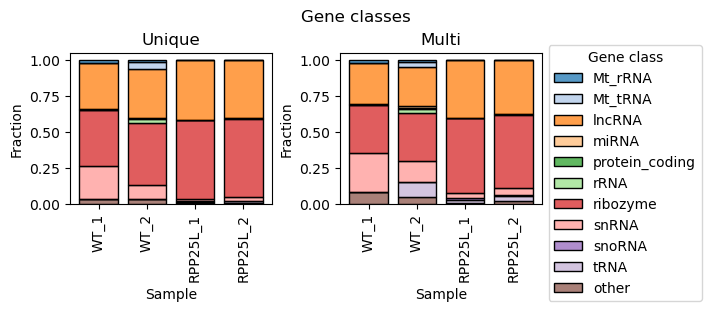

In [11]:
fig, axes = plt.subplots(1,2, figsize=(7, 3), layout='constrained')
sns.histplot(bar_uniq_plot.reset_index().melt('index', var_name='Gene class'), x='index', hue='Gene class', weights='value',
             multiple='stack', palette='tab20', shrink=0.8, ax=axes[0])
sns.histplot(bar_multi_plot.reset_index().melt('index', var_name='Gene class'), x='index', hue='Gene class', weights='value',
             multiple='stack', palette='tab20', shrink=0.8, ax=axes[1])
axes[0].get_legend().remove()
legend = axes[1].get_legend()
legend.set_bbox_to_anchor((1, 1.1))
for ax in axes:
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylabel('Fraction')
    ax.set_xlabel('Sample')
axes[0].set_title("Unique")
axes[1].set_title("Multi")
plt.suptitle("Gene classes")
plt.savefig('00_RPP25L_read_classes_unique_comparison.png', dpi=300, bbox_inches='tight')

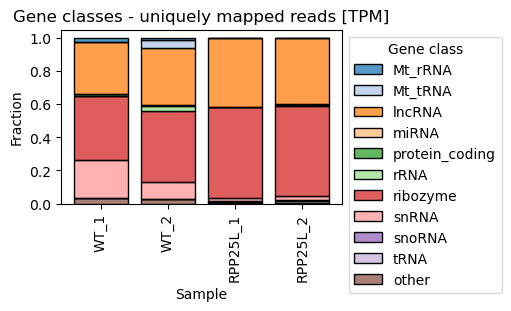

In [12]:
fig, ax = plt.subplots(figsize=(5, 3), layout='constrained')
sns.histplot(bar_uniq_plot.reset_index().melt('index', var_name='Gene class'), x='index', hue='Gene class', weights='value',
             multiple='stack', palette='tab20', shrink=0.8, ax=ax)
legend = ax.get_legend()
legend.set_bbox_to_anchor((1, 1))
ax.set_ylabel('Fraction')
ax.set_xlabel('Sample')
ax.tick_params(axis='x', rotation=90)
plt.title("Gene classes - uniquely mapped reads [TPM]")
plt.savefig('00_RPP25L_read_classes_unique_TPMonly.png', dpi=300, bbox_inches='tight')

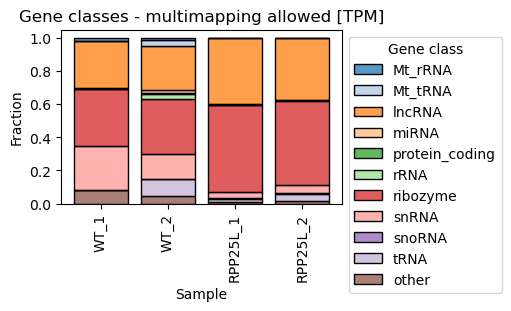

In [13]:
fig, ax = plt.subplots(figsize=(5, 3), layout='constrained')
sns.histplot(bar_multi_plot.reset_index().melt('index', var_name='Gene class'), x='index', hue='Gene class', weights='value',
             multiple='stack', palette='tab20', shrink=0.8, ax=ax)
legend = ax.get_legend()
legend.set_bbox_to_anchor((1, 1))
ax.set_ylabel('Fraction')
ax.set_xlabel('Sample')
ax.tick_params(axis='x', rotation=90)
plt.title("Gene classes - multimapping allowed [TPM]")
plt.savefig('00_RPP25L_read_classes_multi_TPMonly.png', dpi=300, bbox_inches='tight')

### RPPH1 and RMRP

In [14]:
df_targets = pd.DataFrame({
    "RPPH1": df00_uniq[df00_uniq['gene_name'].str.contains('RPPH1', na=False)].sum(numeric_only=True),
    "RMRP": df00_uniq[df00_uniq['gene_name'].str.contains('RMRP', na=False)].sum(numeric_only=True),
})
df_targets['other'] = 1000000 - df_targets.sum(axis=1)
df_targets = df_targets.T.reset_index().rename(columns={"index": "gene"})
df_targets_plot = df_targets.melt(id_vars="gene", var_name="sample", value_name="percentage")
df_targets_plot['percentage'] = df_targets_plot['percentage'] / 1000000

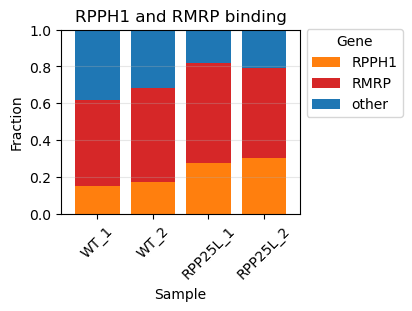

In [15]:
plot_targets = (
    df_targets_plot
    .pivot_table(index="sample", columns="gene", values="percentage", aggfunc="sum")
    .reindex(
        index=["WT_1", "WT_2", "RPP25L_1", "RPP25L_2"],
        columns=["RPPH1", "RMRP", "other"]
    )
    .fillna(0)
)

fig, axes = plt.subplots(figsize=(4,3), layout='constrained')
plot_targets.plot(
    kind="bar",
    stacked=True,
    width=0.8,
    color=['tab:orange', "tab:red", "tab:blue"],
    ax = axes
)

axes.set_title("RPPH1 and RMRP binding")
axes.set_xlabel("Sample")
axes.set_ylabel("Fraction")
axes.set_ylim(0, 1)
axes.tick_params(axis="x", rotation=45)
axes.legend(title="Gene", bbox_to_anchor=(1.46, 1.04), loc="upper right")
axes.grid(axis="y", alpha=0.3)
plt.savefig("00_RPP25L_RPPH1_RMRP_binding.png", dpi=300, bbox_inches='tight')

### Top hits table

In [16]:
df_hits = df00_uniq.copy().assign(RPP25L_mean=lambda x: x[['RPP25L_1', 'RPP25L_2']].mean(axis=1))
df_hits = df_hits.sort_values('RPP25L_mean', ascending=False)
df_hits.to_csv("00_RPP25L_uniq_hits_sorted_by_RPP25L_mean.csv", index=False)
df_hits.head(20)

,WT_1,WT_2,RPP25L_1,RPP25L_2,gene_type,gene_name,RPP25L_mean
ENSG00000277209.1,151956.537618,170716.173201,273280.412800,299780.331414,ribozyme,RPPH1,286530.372107
ENSG00000277027.1,234266.328828,257205.901101,273686.429917,246866.630527,ribozyme,RMRP,260276.530222
ENSG00000269900.3,230769.816457,253367.007055,269601.557828,243182.053952,lncRNA,RMRP,256391.805890
ENSG00000259001.3,79312.738287,89104.209523,142636.955270,156468.417493,lncRNA,ENSG00000259001,149552.686382
ENSG00000202538.1,159500.479202,0.000000,4276.240915,4692.572305,snRNA,RNU4-2,4484.406610
tRNA35974,0.000000,0.000000,2392.658607,4594.810382,tRNA,tRNA35974,3493.734495
ENSG00000270722.1,0.000000,0.000000,1050.435486,5043.084566,snRNA,RNVU1-31,3046.760026
tRNA13029,0.000000,0.000000,1196.329304,2297.405191,tRNA,tRNA13029,1746.867247
tRNA31864,0.000000,0.000000,1179.941231,2265.933887,tRNA,tRNA31864,1722.937559
ENSG00000199347.1,0.000000,0.000000,1794.493955,1378.443115,snRNA,RNU5E-1,1586.468535


### Percent values of classes

In [17]:
bar_uniq_plot

,Mt_rRNA,Mt_tRNA,lncRNA,miRNA,protein_coding,rRNA,ribozyme,snRNA,snoRNA,tRNA,other
WT_1,0.021638,0.000000,0.319313,0.000000,0.007588,0.000000,0.386223,0.231266,0.000000,0.000000,0.033972
WT_2,0.010165,0.048023,0.346077,0.000000,0.007588,0.027090,0.429446,0.102885,0.000000,0.000000,0.028727
RPP25L_1,0.000753,0.000000,0.415768,0.000813,0.000638,0.000000,0.546973,0.017729,0.008974,0.006539,0.001812
RPP25L_2,0.000531,0.000000,0.400792,0.000811,0.000462,0.005633,0.547724,0.023043,0.005679,0.011457,0.003869


### Top hits in selected classes

#### snRNA

In [18]:
df_top_snrna = df00_uniq[df00_uniq['gene_type'] == 'snRNA'].copy()
df_top_snrna['RPP25L_mean'] = df_top_snrna[['RPP25L_1', 'RPP25L_2']].mean(axis=1)
df_top_snrna = df_top_snrna.sort_values('RPP25L_mean', ascending=False)
# df_top_snrna.columns = df_top_snrna.columns[-1:].tolist() + df_top_snrna.columns[:-1].tolist()
df_top_snrna.head(15)

,WT_1,WT_2,RPP25L_1,RPP25L_2,gene_type,gene_name,RPP25L_mean
ENSG00000202538.1,159500.479202,0.000000,4276.240915,4692.572305,snRNA,RNU4-2,4484.406610
ENSG00000270722.1,0.000000,0.000000,1050.435486,5043.084566,snRNA,RNVU1-31,3046.760026
ENSG00000199347.1,0.000000,0.000000,1794.493955,1378.443115,snRNA,RNU5E-1,1586.468535
ENSG00000277918.1,0.000000,0.000000,1050.435486,2017.233826,snRNA,RNVU1-28,1533.834656
ENSG00000199568.1,0.000000,0.000000,1485.098446,1425.975636,snRNA,RNU5A-1,1455.537041
ENSG00000274978.1,0.000000,0.000000,2249.813317,617.213335,snRNA,RNU11,1433.513326
ENSG00000200156.1,0.000000,27226.286243,742.549223,1425.975636,snRNA,RNU5B-1,1084.262429
ENSG00000207175.1,0.000000,0.000000,0.000000,2017.233826,snRNA,RNU1-67P,1008.616913
ENSG00000276027.1,37482.612612,10527.497347,861.357099,1102.754492,snRNA,RNU12,982.055795
ENSG00000283293.1,34282.877389,28886.425648,919.131050,1008.616913,snRNA,RN7SK,963.873982


#### snoRNA

In [19]:
df_top_snorna = df00_uniq[df00_uniq['gene_type'] == 'snoRNA'].copy()
df_top_snorna['RPP25L_mean'] = df_top_snorna[['RPP25L_1', 'RPP25L_2']].mean(axis=1)
df_top_snorna = df_top_snorna.sort_values('RPP25L_mean', ascending=False)
# df_top_snorna.columns = df_top_snorna.columns[-1:].tolist() + df_top_snorna.columns[:-1].tolist()
df_top_snorna.head(5)

,WT_1,WT_2,RPP25L_1,RPP25L_2,gene_type,gene_name,RPP25L_mean
ENSG00000207468.1,0.0,0.0,0.000000,1292.290420,snoRNA,SNORA19,646.145210
ENSG00000200087.1,0.0,0.0,1266.701616,0.000000,snoRNA,SNORA73B,633.350808
ENSG00000200394.1,0.0,0.0,0.000000,1262.695983,snoRNA,SNORA38B,631.347991
ENSG00000221514.1,0.0,0.0,1076.696373,0.000000,snoRNA,SNORD111B,538.348187
ENSG00000200983.1,0.0,0.0,331.291192,636.204514,snoRNA,SNORA3A,483.747853


#### rRNA

In [20]:
tsdf = pd.concat([df00_uniq[df00_uniq['gene_type'] == 'rRNA_pseudogene'],
           df00_uniq[df00_uniq['gene_type'] == 'rRNA']])
tsdf['RPP25L_mean'] = tsdf[['RPP25L_1', 'RPP25L_2']].mean(axis=1)
tsdf = tsdf.sort_values('RPP25L_mean', ascending=False)
# tsdf = tsdf.drop(columns=['gene_type']).apply(lambda x: x/sum(x), axis=1)
tsdf

,WT_1,WT_2,RPP25L_1,RPP25L_2,gene_type,gene_name,RPP25L_mean
ENSG00000199523.1,0.0,0.000000,0.0,1438.375424,rRNA_pseudogene,RNA5SP226,719.187712
ENSG00000199843.1,0.0,26993.582942,0.0,1413.787810,rRNA_pseudogene,RNA5SP358,706.893905
ENSG00000201185.1,0.0,0.000000,0.0,1390.026670,rRNA_pseudogene,RNA5SP202,695.013335
ENSG00000199839.1,0.0,0.000000,0.0,1390.026670,rRNA,RNA5SP150,695.013335
ENSG00000222308.1,0.0,0.000000,0.0,0.000000,rRNA_pseudogene,RNA5SP198,0.000000
...,...,...,...,...,...,...,...
ENSG00000252647.1,0.0,0.000000,0.0,0.000000,rRNA_pseudogene,RNA5SP416,0.000000
ENSG00000253055.1,0.0,0.000000,0.0,0.000000,rRNA_pseudogene,RNA5SP415,0.000000
ENSG00000274228.1,0.0,0.000000,0.0,0.000000,rRNA_pseudogene,RNA5SP414,0.000000
ENSG00000252182.1,0.0,0.000000,0.0,0.000000,rRNA_pseudogene,RNA5SP413,0.000000


## Target/classes plot for MS

In [21]:
df10_targets =df00_uniq.copy()
df10_targets.loc[df10_targets['gene_name'].str.contains('RPPH1', na=False), 'gene_type'] = 'RPPH1'
df10_targets.loc[df10_targets['gene_name'].str.contains('RMRP', na=False), 'gene_type'] = 'RMRP'

In [22]:
# Calculate percentages for barplot
bar_target_uniq = df10_targets.reset_index().groupby('gene_type').agg('sum', numeric_only=True).T.apply(lambda x: x/sum(x), axis=1) # type: ignore

#filter out some classes and sum them into 'other'
keep = [
    'lncRNA',
    # 'polymorphic_pseudogene',
    # 'rRNA_pseudogene',
    # 'snRNA',
    'RPPH1', 'RMRP',
    # 'miRNA', 'protein_coding', 'ribozyme', 'snoRNA',
    # 'Mt_rRNA', 'Mt_tRNA',
    # 'tRNA', 'rRNA',
]

bar_target_uniq_keep = bar_target_uniq.loc[:,bar_target_uniq.columns.isin(keep)]
# bar_target_uniq_keep['rRNA'] = bar_target_uniq_keep['rRNA'] + bar_target_uniq_keep['rRNA_pseudogene']
# bar_target_uniq_keep = bar_target_uniq_keep.drop(columns=['rRNA_pseudogene'])
bar_target_uniq_plot = pd.concat([bar_target_uniq_keep, pd.DataFrame(bar_target_uniq.loc[:,~bar_target_uniq.columns.isin(keep)].sum(axis=1))], axis=1)
bar_target_uniq_plot = bar_target_uniq_plot.rename({0: 'other'}, axis=1)

In [23]:
bar_target_uniq_plot

,RMRP,RPPH1,lncRNA,other
WT_1,0.465036,0.151957,0.088543,0.294464
WT_2,0.512391,0.171324,0.091808,0.224477
RPP25L_1,0.543294,0.273284,0.146163,0.037259
RPP25L_2,0.490093,0.300835,0.157588,0.051485


In [24]:
bar_target_uniq.loc[bar_target_uniq.index.str.contains('RPP25L'),~bar_target_uniq.columns.isin(keep)].T.sort_values('RPP25L_1', ascending=False)

,RPP25L_1,RPP25L_2
gene_type,,
snRNA,0.017729,0.023043
snoRNA,0.008974,0.005679
tRNA,0.006539,0.011457
misc_RNA,0.001473,0.003820
miRNA,0.000813,0.000811
Mt_rRNA,0.000753,0.000531
protein_coding,0.000638,0.000462
scaRNA,0.000339,0.000000
transcribed_unitary_pseudogene,0.000000,0.000000


In [25]:
bar_target_uniq.loc[bar_target_uniq.index.str.contains('RPP25L'),~bar_target_uniq.columns.isin(keep)].T.sort_values('RPP25L_1', ascending=False).sum()

RPP25L_1    0.037259
RPP25L_2    0.051485
dtype: float64

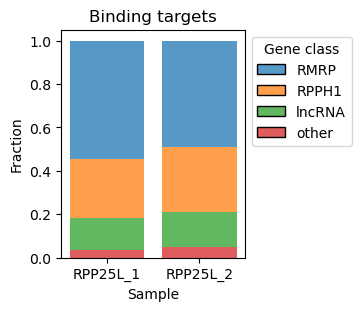

In [26]:
fig, ax = plt.subplots(figsize=(3.5, 3), layout='constrained')
sns.histplot(bar_target_uniq_plot.loc[bar_target_uniq_plot.index.str.contains('RPP25L')].reset_index().melt('index', var_name='Gene class'), x='index', hue='Gene class', weights='value',
             multiple='stack', palette='tab10', shrink=0.8, ax=ax)
legend = ax.get_legend()
legend.set_bbox_to_anchor((1, 1))
ax.set_ylabel('Fraction')
ax.set_xlabel('Sample')
for patch in ax.patches:
    patch.set_linewidth(0)
    patch.set_edgecolor('none')
# ax.grid(axis='y', alpha=0.3)
# ax.tick_params(axis='x', rotation=45)
# for tick in ax.get_xticklabels():
#     tick.set_horizontalalignment("right")
#     tick.set_rotation_mode("anchor")
plt.title("Binding targets")
plt.savefig('00_RPP25L_binding_targets_for_MS.png', dpi=300, bbox_inches='tight')

In [27]:
bar_target_uniq_plot

,RMRP,RPPH1,lncRNA,other
WT_1,0.465036,0.151957,0.088543,0.294464
WT_2,0.512391,0.171324,0.091808,0.224477
RPP25L_1,0.543294,0.273284,0.146163,0.037259
RPP25L_2,0.490093,0.300835,0.157588,0.051485
